# load filtered data

In [12]:
import glob
glob.glob("../../data/enriched/filtered/enriched_batch_*.jsonl") #/enriched/filtered/einriched_batch_*.jsonl")

['../../data/enriched/filtered/enriched_batch_1.jsonl',
 '../../data/enriched/filtered/enriched_batch_2.jsonl',
 '../../data/enriched/filtered/enriched_batch_3.jsonl',
 '../../data/enriched/filtered/enriched_batch_4.jsonl']

In [1]:
# load the filtered data
# import all semscho papers before any filtering
import pandas as pd
import glob
import json

# ---------------------------------------------------
# 1. Find all batch files
# ---------------------------------------------------

#files = glob.glob("../../data/processed/search_results_batch_*.jsonl")
files = glob.glob("../../data/enriched/filtered/enriched_batch_*.jsonl")

print(f"Found {len(files)} files")

# ---------------------------------------------------
# 2. Load all records
# ---------------------------------------------------

records = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"Skipping malformed line in {file}")

# ---------------------------------------------------
# 3. Convert to DataFrame
# ---------------------------------------------------

papers_df = pd.DataFrame(records)

print(papers_df.shape)
print(papers_df.columns)

Found 4 files
(311686, 33)
Index(['paperId', 'title', 'venue', 'year', 'citationCount', 'fieldsOfStudy',
       'publicationTypes', 'authors', 'abstract', 'doi', 'pdf_url', 'oa_id',
       'oa_title', 'oa_publication_year', 'oa_language', 'oa_type',
       'oa_is_retracted', 'oa_cited_by_count',
       'oa_citation_normalized_percentile', 'oa_authors',
       'oa_source_display_name', 'oa_source_issn', 'oa_source_issn_l',
       'oa_source_type', 'oa_source_host_organization_name', 'oa_pdf_url',
       'oa_topics', 'oa_keywords', 'oa_concepts', 'oa_has_pdf',
       'oa_has_grobid_xml', 'oa_content_urls', 'abstract_source'],
      dtype='str')


n/a 79M
Medicine 58M
Engineering 30M
Environmental Science 22M
Biology 21M
Computer Science 19M
Chemistry 18M
Physics 16M
Materials Science 16M
Psychology 9.9M
Sociology 8.1M
Political Science 8.0M
Business 7.9M
Education 7.5M
History 7.4M
Mathematics 6.9M
Economics 6.6M
Agricultural and Food Sciences 5.7M
Geography 4.6M
Geology 3.7M
Art 3.6M
Law 3.2M
Philosophy 3.0M
Linguistics 2.0M
Agricultural And Food Sciences 83k

In [3]:
full_dataset = [
    {"n/a": 79},
    {"Medicine": 58},
    {"Engineering": 30},
    {"Environmental Science": 22},
    {"Biology": 21},
    {"Computer Science": 19},
    {"Chemistry": 18},
    {"Physics": 16},
    {"Materials Science": 16},
    {"Psychology": 9.9},
    {"Sociology": 8.1},
    {"Political Science": 8.0},
    {"Business": 7.9},
    {"Education": 7.5},
    {"History": 7.4},
    {"Mathematics": 6.9},
    {"Economics": 6.6},
    {"Agricultural and Food Sciences": 5.783},
    {"Geography": 4.6},
    {"Geology": 3.7},
    {"Art": 3.6},
    {"Law": 3.2},
    {"Philosophy": 3.0},
    {"Linguistics": 2.0},
]

df = pd.DataFrame(
    [
        {"fos_db": key, "counts": value}
        for d in full_dataset
        for key, value in d.items()
    ]
)

df

,fos_db,counts
0,n/a,79.000
1,Medicine,58.000
2,Engineering,30.000
3,Environmental Science,22.000
4,Biology,21.000
5,Computer Science,19.000
6,Chemistry,18.000
7,Physics,16.000
8,Materials Science,16.000
9,Psychology,9.900


In [4]:
# --------------------------------------------------
# 1. Expand fieldsOfStudy
# --------------------------------------------------

papers_exploded = papers_df.explode("fieldsOfStudy")

# Replace missing fields with "n/a"
papers_exploded["fieldsOfStudy"] = (
    papers_exploded["fieldsOfStudy"]
    .fillna("n/a")
)

# --------------------------------------------------
# 2. Count papers per field
# --------------------------------------------------

df_paper = (
    papers_exploded
    .groupby("fieldsOfStudy")
    .size()
    .reset_index(name="paper_count")
)

df_paper

,fieldsOfStudy,paper_count
0,Art,14572
1,Biology,800
2,Business,2514
3,Chemistry,99
4,Computer Science,13447
5,Economics,2171
6,Engineering,1334
7,Environmental Science,232
8,Geography,3200
9,Geology,228


In [5]:
# Rename count column in df
df = df.rename(columns={"counts": "df_count"})

# Normalize names for matching
df["fos_db_clean"] = (
    df["fos_db"]
    .str.strip()
    .str.lower()
)

df_paper["fos_clean"] = (
    df_paper["fieldsOfStudy"]
    .str.strip()
    .str.lower()
)

# Merge
merged = df.merge(
    df_paper,
    left_on="fos_db_clean",
    right_on="fos_clean",
    how="outer"
)

# Use original names for display
merged["fos_db"] = merged["fos_db"].fillna(
    merged["fieldsOfStudy"]
)

# Fill missing counts with 0
merged["df_count"] = merged["df_count"].fillna(0)
merged["paper_count"] = merged["paper_count"].fillna(0)

# Clean up helper columns
merged = merged.drop(
    columns=["fieldsOfStudy", "fos_db_clean", "fos_clean"]
)

merged = merged.sort_values("df_count", ascending=False)

merged

,fos_db,df_count,paper_count
18,n/a,79.000,134904.0
17,Medicine,58.000,46184.0
8,Engineering,30.000,1334.0
9,Environmental Science,22.000,232.0
2,Biology,21.000,800.0
5,Computer Science,19.000,13447.0
4,Chemistry,18.000,99.0
15,Materials Science,16.000,92.0
20,Physics,16.000,620.0
22,Psychology,9.900,25206.0


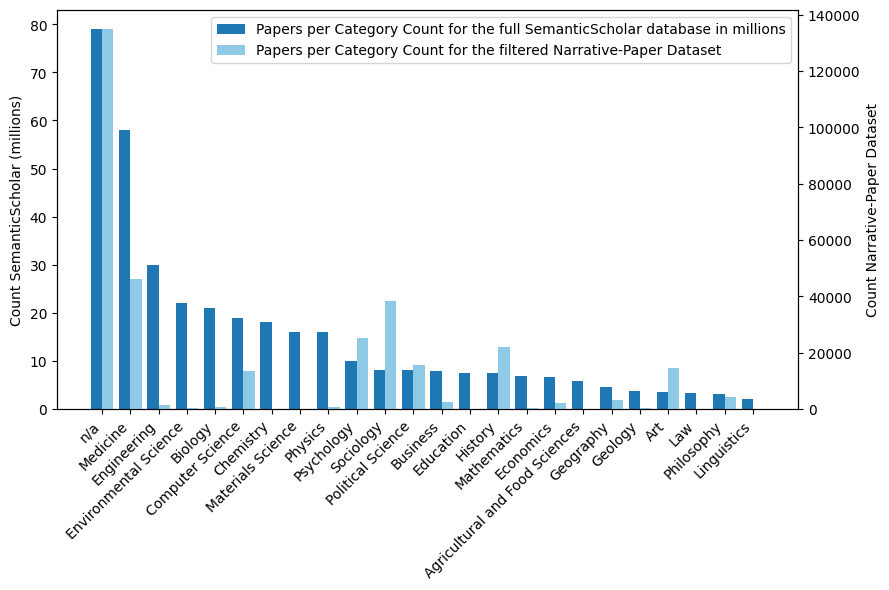

In [6]:
import matplotlib.pyplot as plt
import numpy as np
#
fig, ax1 = plt.subplots(figsize=(9, 6))

x = np.arange(len(merged))
width = 0.4

# df — counts are already in millions
bars1 = ax1.bar(
    x - width / 2,
    merged["df_count"],
    width,
    label="Papers per Category Count for the full SemanticScholar database in millions"
)

ax1.set_ylabel("Count SemanticScholar (millions)")
ax1.set_xlabel("")

# Second y-axis
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width / 2,
    merged["paper_count"],
    width,
    label="Papers per Category Count for the filtered Narrative-Paper Dataset",
    color="#8ecae6"
)

ax2.set_ylabel("Count Narrative-Paper Dataset")

# X labels
ax1.set_xticks(x)
ax1.set_xticklabels(
    merged["fos_db"],
    rotation=45,
    ha="right"
)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper right"
)

#plt.title("Database Counts vs. Paper Counts by Field of Study")
plt.tight_layout()
plt.show()